# 04 - ResNet18 Transfer Learning

This notebook trains and evaluates a pretrained ResNet18 model using the fixed train/validation/test split created in `01_dataset_preparation.ipynb`.

The dataset split is not modified in this notebook.

The final ResNet18 results will be compared against:
- Baseline CNN
- Frozen MobileNetV2
- Fine-Tuned MobileNetV2

In [48]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
import random
import time
import copy
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [50]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [51]:
from pathlib import Path

# Use the exact shortcut target path resolved by Google Colab
PROJECT_DIR = Path(
    "/content/drive/.shortcut-targets-by-id/1JdUyW7HmGCTe1weABU3nR1dOGsFM1_Ag/e23-co5430-Surface-Defect-Detection"
)

TRAIN_DIR = PROJECT_DIR / "dataset" / "split" / "train"
VALIDATION_DIR = PROJECT_DIR / "dataset" / "split" / "validation"
TEST_DIR = PROJECT_DIR / "dataset" / "split" / "test"

MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results" / "resnet18"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project Path:", PROJECT_DIR.exists())
print("Train:", TRAIN_DIR.exists())
print("Validation:", VALIDATION_DIR.exists())
print("Test:", TEST_DIR.exists())

Project Path: True
Train: True
Validation: True
Test: True


In [52]:
assert TRAIN_DIR.exists(), "Training split not found"
assert VALIDATION_DIR.exists(), "Validation split not found"
assert TEST_DIR.exists(), "Test split not found"

print("Using fixed split from 01_dataset_preparation.ipynb")

Using fixed split from 01_dataset_preparation.ipynb


In [53]:
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [54]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

validation_dataset = datasets.ImageFolder(
    VALIDATION_DIR,
    transform=evaluation_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=evaluation_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Test:", len(test_dataset))

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

Train: 1260
Validation: 270
Test: 270
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']
Class mapping: {'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled_in_scale': 4, 'scratches': 5}


In [55]:
assert train_dataset.classes == validation_dataset.classes
assert train_dataset.classes == test_dataset.classes

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(CLASS_NAMES)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled_in_scale', 'scratches']


In [56]:
test_files = sorted([
    str(Path(path).relative_to(PROJECT_DIR))
    for path, _ in test_dataset.samples
])

test_signature = hashlib.sha256(
    "\n".join(test_files).encode()
).hexdigest()

print("Number of test files:", len(test_files))
print("Test-set signature:", test_signature)

Number of test files: 270
Test-set signature: 5eb766167cea0edfc0662ea754c9938bd645ed30b3cf33ff614e9c28a8770213


In [57]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [59]:
weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(
    weights=weights
)

print("ResNet18 loaded")

ResNet18 loaded


In [60]:
for param in model.parameters():
    param.requires_grad = False

In [61]:
input_features = model.fc.in_features

model.fc = nn.Linear(
    input_features,
    NUM_CLASSES
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=6, bias=True)


In [62]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

Total parameters: 11,179,590
Trainable parameters: 3,078


In [63]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

EPOCHS = 10

In [64]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss / len(dataloader.dataset)
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy

In [65]:
def validate(
    model,
    dataloader,
    criterion
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    epoch_loss = (
        running_loss / len(dataloader.dataset)
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy

In [66]:
train_losses = []
validation_losses = []

train_accuracies = []
validation_accuracies = []

best_validation_accuracy = 0.0

best_model_weights = copy.deepcopy(
    model.state_dict()
)

start_time = time.time()

for epoch in range(EPOCHS):

    train_loss, train_accuracy = (
        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )
    )

    validation_loss, validation_accuracy = (
        validate(
            model,
            validation_loader,
            criterion
        )
    )

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    train_accuracies.append(train_accuracy)
    validation_accuracies.append(
        validation_accuracy
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy*100:.2f}% | "
        f"Val Loss: {validation_loss:.4f} | "
        f"Val Acc: {validation_accuracy*100:.2f}%"
    )

    if validation_accuracy > best_validation_accuracy:

        best_validation_accuracy = (
            validation_accuracy
        )

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

training_time = (
    time.time() - start_time
)

model.load_state_dict(
    best_model_weights
)

print(
    f"\nBest validation accuracy: "
    f"{best_validation_accuracy*100:.2f}%"
)

print(
    f"Training time: "
    f"{training_time/60:.2f} minutes"
)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Train Loss: 1.1502 | Train Acc: 66.03% | Val Loss: 0.8479 | Val Acc: 83.33%
Epoch 2/10 | Train Loss: 0.4630 | Train Acc: 92.30% | Val Loss: 0.3238 | Val Acc: 96.30%
Epoch 3/10 | Train Loss: 0.3075 | Train Acc: 94.60% | Val Loss: 0.2025 | Val Acc: 97.41%
Epoch 4/10 | Train Loss: 0.2376 | Train Acc: 95.87% | Val Loss: 0.1686 | Val Acc: 97.41%
Epoch 5/10 | Train Loss: 0.1992 | Train Acc: 96.11% | Val Loss: 0.1376 | Val Acc: 97.41%
Epoch 6/10 | Train Loss: 0.1589 | Train Acc: 97.62% | Val Loss: 0.1138 | Val Acc: 98.15%
Epoch 7/10 | Train Loss: 0.1600 | Train Acc: 96.11% | Val Loss: 0.1024 | Val Acc: 98.15%
Epoch 8/10 | Train Loss: 0.1342 | Train Acc: 97.46% | Val Loss: 0.0821 | Val Acc: 98.52%
Epoch 9/10 | Train Loss: 0.1217 | Train Acc: 97.06% | Val Loss: 0.0823 | Val Acc: 98.89%
Epoch 10/10 | Train Loss: 0.1185 | Train Acc: 97.54% | Val Loss: 0.0755 | Val Acc: 98.89%

Best validation accuracy: 98.89%
Training time: 34.33 minutes


In [67]:
RESNET_MODEL_PATH = (
    MODELS_DIR / "resnet18.pth"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": CLASS_NAMES,
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
        "best_validation_accuracy":
            best_validation_accuracy
    },
    RESNET_MODEL_PATH
)

print("Saved:", RESNET_MODEL_PATH)

Saved: /content/drive/.shortcut-targets-by-id/1JdUyW7HmGCTe1weABU3nR1dOGsFM1_Ag/e23-co5430-Surface-Defect-Detection/models/resnet18.pth


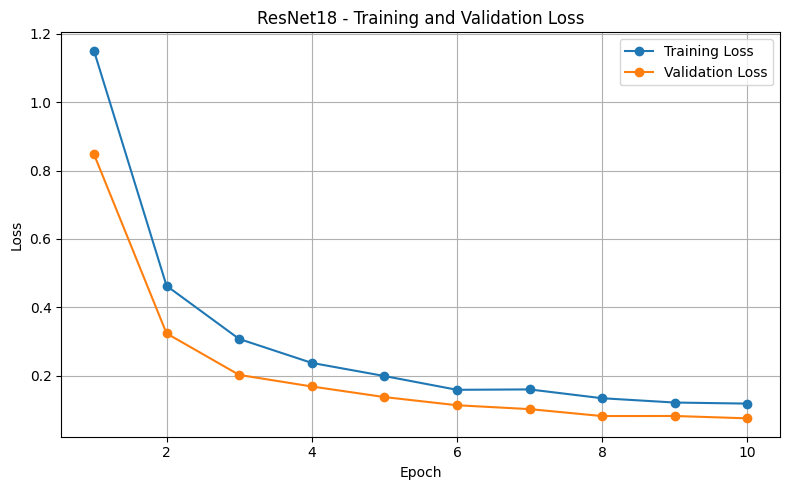

In [68]:
epochs_range = range(
    1,
    len(train_losses) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    validation_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "ResNet18 - Training and Validation Loss"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

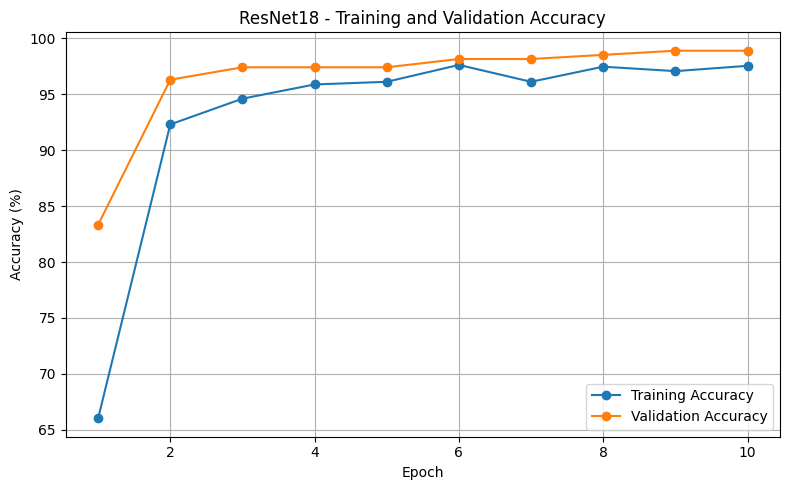

In [69]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    [x * 100 for x in train_accuracies],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    [x * 100 for x in validation_accuracies],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "ResNet18 - Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
model.eval()

all_labels = []
all_predictions = []
all_confidences = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predicted = torch.max(
            probabilities,
            dim=1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_confidences.extend(
            confidence.cpu().numpy()
        )

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_confidences = np.array(all_confidences)

In [71]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

print(
    f"Test Accuracy: {accuracy*100:.2f}%"
)

print(
    f"Macro Precision: {precision*100:.2f}%"
)

print(
    f"Macro Recall: {recall*100:.2f}%"
)

print(
    f"Macro F1: {f1*100:.2f}%"
)

Test Accuracy: 98.15%
Macro Precision: 98.17%
Macro Recall: 98.15%
Macro F1: 98.15%


In [72]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=CLASS_NAMES,
    zero_division=0
)

print(report)

with open(
    RESULTS_DIR / "classification_report.txt",
    "w"
) as file:

    file.write(report)

                 precision    recall  f1-score   support

        crazing       0.96      1.00      0.98        45
      inclusion       0.98      0.96      0.97        45
        patches       1.00      1.00      1.00        45
 pitted_surface       0.98      0.98      0.98        45
rolled_in_scale       1.00      0.98      0.99        45
      scratches       0.98      0.98      0.98        45

       accuracy                           0.98       270
      macro avg       0.98      0.98      0.98       270
   weighted avg       0.98      0.98      0.98       270



In [73]:
metrics_df = pd.DataFrame([
    {
        "Model": "ResNet18",
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1,
        "Best Validation Accuracy":
            best_validation_accuracy,
        "Epochs": EPOCHS,
        "Training Time Seconds":
            training_time
    }
])

display(metrics_df)

metrics_df.to_csv(
    RESULTS_DIR / "metrics.csv",
    index=False
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Best Validation Accuracy,Epochs,Training Time Seconds
0,ResNet18,0.981481,0.981713,0.981481,0.981479,0.988889,10,2059.637449


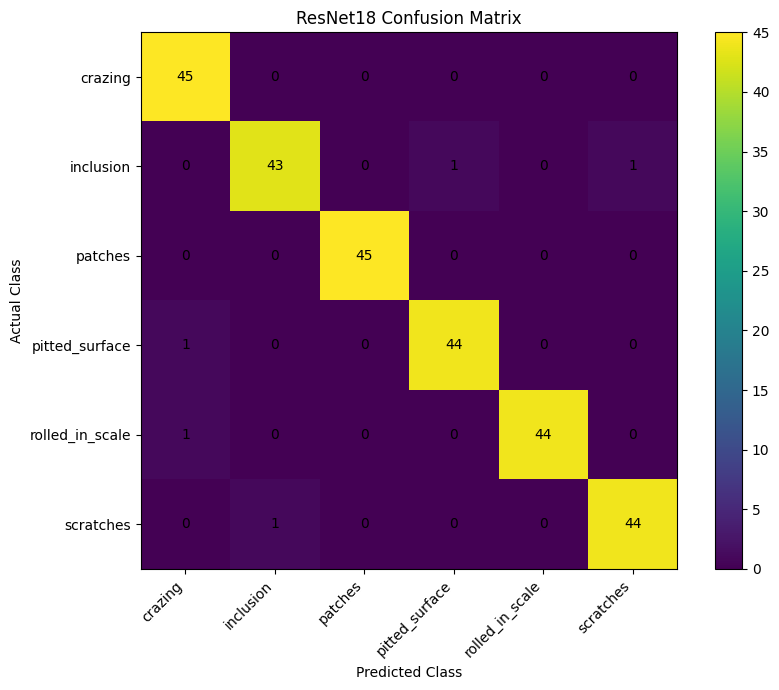

In [74]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.title(
    "ResNet18 Confusion Matrix"
)

plt.colorbar()

ticks = np.arange(
    len(CLASS_NAMES)
)

plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks,
    CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [75]:
predictions_df = pd.DataFrame({
    "Actual Class": [
        CLASS_NAMES[x]
        for x in all_labels
    ],

    "Predicted Class": [
        CLASS_NAMES[x]
        for x in all_predictions
    ],

    "Confidence":
        all_confidences,

    "Correct":
        all_labels == all_predictions
})

predictions_df.to_csv(
    RESULTS_DIR / "test_predictions.csv",
    index=False
)

display(
    predictions_df.head()
)

,Actual Class,Predicted Class,Confidence,Correct
0,crazing,crazing,0.998411,True
1,crazing,crazing,0.995489,True
2,crazing,crazing,0.996045,True
3,crazing,crazing,0.994639,True
4,crazing,crazing,0.971599,True


In [76]:
failure_indices = np.where(
    all_labels != all_predictions
)[0]

print(
    "Number of incorrect predictions:",
    len(failure_indices)
)

Number of incorrect predictions: 5


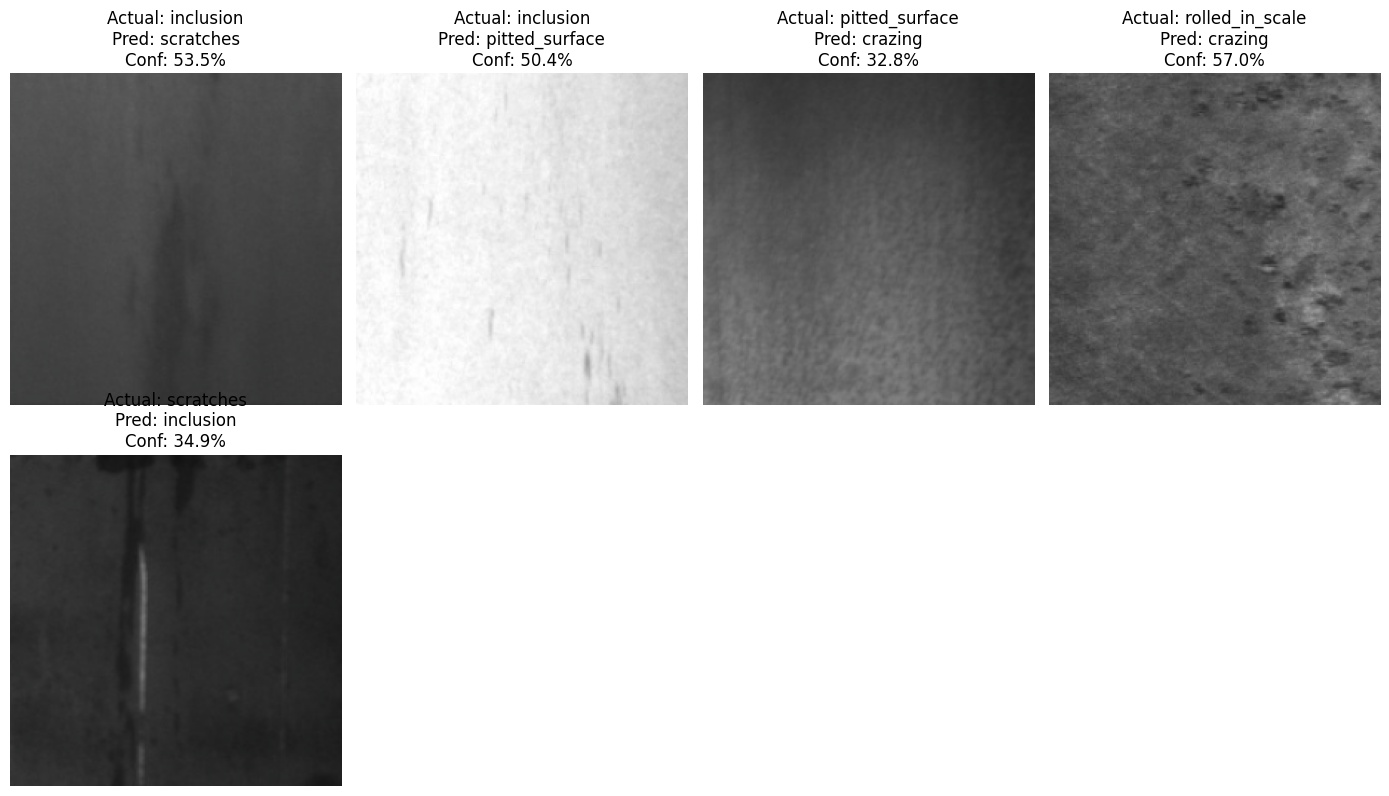

In [77]:
def denormalize_image(image):

    image = (
        image.cpu()
        .numpy()
        .transpose(1, 2, 0)
    )

    mean = np.array(
        [0.485, 0.456, 0.406]
    )

    std = np.array(
        [0.229, 0.224, 0.225]
    )

    image = image * std + mean

    return np.clip(
        image,
        0,
        1
    )


if len(failure_indices) > 0:

    count = min(
        8,
        len(failure_indices)
    )

    plt.figure(
        figsize=(14, 8)
    )

    for position, index in enumerate(
        failure_indices[:count]
    ):

        image, _ = test_dataset[index]

        plt.subplot(
            2,
            4,
            position + 1
        )

        plt.imshow(
            denormalize_image(image)
        )

        plt.title(
            f"Actual: "
            f"{CLASS_NAMES[all_labels[index]]}\n"
            f"Pred: "
            f"{CLASS_NAMES[all_predictions[index]]}\n"
            f"Conf: "
            f"{all_confidences[index]*100:.1f}%"
        )

        plt.axis("off")

    plt.tight_layout()

    plt.savefig(
        RESULTS_DIR / "failure_cases.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:
    print(
        "No failure cases — "
        "all test samples classified correctly."
    )